# Import Libraries

In [182]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Initial Exploration

In [183]:
df = pd.read_csv("ecommerce_sales_analytics_5000.csv")
df

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue
0,10001,1/1/2022,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20
1,10002,1/2/2022,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10
2,10003,1/3/2022,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35
3,10004,1/4/2022,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90
4,10005,1/5/2022,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56
...,...,...,...,...,...,...,...,...,...,...,...,...
4995,14996,9/5/2035,1289,Clothing,West,2,371.74,0.27,COD,3,2.3,542.74
4996,14997,9/6/2035,1294,Beauty,North,3,553.67,0.14,COD,11,2.2,1428.47
4997,14998,9/7/2035,1450,Beauty,West,3,77.22,0.24,Wallet,6,3.4,176.06
4998,14999,9/8/2035,1903,Electronics,South,4,138.41,0.21,COD,4,2.8,437.38


In [184]:
df.shape

(5000, 12)

In [185]:
df.columns.to_list()

['order_id',
 'order_date',
 'customer_id',
 'product_category',
 'region',
 'quantity',
 'unit_price',
 'discount',
 'payment_method',
 'delivery_days',
 'customer_rating',
 'revenue']

In [186]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          5000 non-null   int64  
 1   order_date        5000 non-null   object 
 2   customer_id       5000 non-null   int64  
 3   product_category  5000 non-null   object 
 4   region            5000 non-null   object 
 5   quantity          5000 non-null   int64  
 6   unit_price        5000 non-null   float64
 7   discount          5000 non-null   float64
 8   payment_method    5000 non-null   object 
 9   delivery_days     5000 non-null   int64  
 10  customer_rating   5000 non-null   float64
 11  revenue           5000 non-null   float64
dtypes: float64(4), int64(4), object(4)
memory usage: 468.9+ KB


# Data Quality

In [187]:
df.isnull().sum()

order_id            0
order_date          0
customer_id         0
product_category    0
region              0
quantity            0
unit_price          0
discount            0
payment_method      0
delivery_days       0
customer_rating     0
revenue             0
dtype: int64

In [188]:
df.duplicated().sum()

np.int64(0)

In [189]:
df.nunique()

order_id            5000
order_date          5000
customer_id          989
product_category       4
region                 4
quantity               7
unit_price          4788
discount              36
payment_method         3
delivery_days         11
customer_rating       41
revenue             4940
dtype: int64

In [190]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
order_id,5000.0,12500.500000,1443.520003,10001.00,11250.7500,12500.50,13750.2500,15000.00
customer_id,5000.0,1505.701200,290.836902,1000.00,1253.0000,1510.00,1761.0000,1999.00
quantity,5000.0,4.044800,2.020398,1.00,2.0000,4.00,6.0000,7.00
unit_price,5000.0,308.418774,169.259369,15.15,161.8950,309.89,455.5575,599.96
discount,5000.0,0.179984,0.101404,0.00,0.0900,0.18,0.2700,0.35
delivery_days,5000.0,6.118800,3.153264,1.00,3.0000,6.00,9.0000,11.00
customer_rating,5000.0,2.973980,1.157722,1.00,2.0000,3.00,4.0000,5.00
revenue,5000.0,1021.955148,825.584219,11.21,354.5275,796.65,1515.6900,4119.33


In [191]:
df['order_date'] = pd.to_datetime(df['order_date'])

In [192]:
df.dtypes

order_id                     int64
order_date          datetime64[ns]
customer_id                  int64
product_category            object
region                      object
quantity                     int64
unit_price                 float64
discount                   float64
payment_method              object
delivery_days                int64
customer_rating            float64
revenue                    float64
dtype: object

# Create Useful Variables

In [193]:
df['year'] = df['order_date'].dt.year

In [194]:
df['year_month'] = df['order_date'].dt.to_period("M").astype(str)

In [195]:
df['month'] = df['order_date'].dt.month

In [196]:
df['month_name'] = df['order_date'].dt.month_name()

In [197]:
df['sales'] = df['quantity']*df['unit_price']

In [198]:
df['discount_amount'] = df['sales']*df['discount']

# Basic KPIs

In [199]:
total_orders = df['order_id'].nunique()
print(f'total orders : {total_orders}')

total orders : 5000


In [200]:
total_customers = df['customer_id'].nunique()
print(f'total customers : {total_customers}')

total customers : 989


In [201]:
total_sales = df['sales'].sum()
print(f'total sales : {total_sales}')

total sales : 6240021.96


In [202]:
total_revenue = df['revenue'].sum()
print(f'total revenue : {total_revenue}')

total revenue : 5109775.74


In [203]:
total_quantity = df['quantity'].sum()
print(f'total quantity : {total_quantity}')

total quantity : 20224


In [204]:
average_order_value = df.groupby('order_id')['revenue'].sum().mean()
print(f'average order value : {average_order_value:.4f}')

average order value : 1021.9551


In [205]:
average_rating = df['customer_rating'].mean()
print(f'average customer rating : {average_rating:.4f}')

average customer rating : 2.9740


In [206]:
average_delivery = df['delivery_days'].mean()
print(f'average delivery time : {average_delivery}')

average delivery time : 6.1188


# Revenue Analysis

In [207]:
monthly_revenue = (
    df.groupby('year_month')['revenue'].sum().reset_index()
)
monthly_revenue

,year_month,revenue
0,2022-01,35624.89
1,2022-02,29908.89
2,2022-03,30309.28
3,2022-04,30781.96
4,2022-05,41629.24
...,...,...
160,2035-05,33393.87
161,2035-06,25205.26
162,2035-07,23944.48
163,2035-08,29354.74


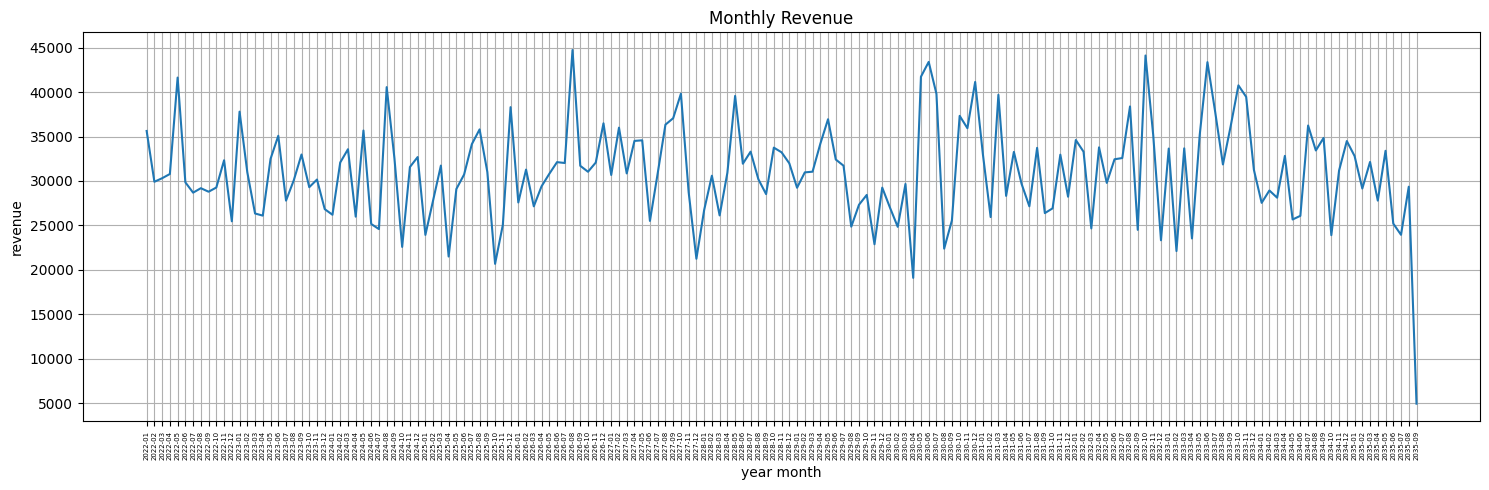

<Figure size 640x480 with 0 Axes>

In [225]:
plt.figure(figsize=(15,5))

plt.plot(monthly_revenue['year_month'],monthly_revenue['revenue'])
plt.title("Monthly Revenue")
plt.xlabel("year month")
plt.ylabel("revenue")
plt.xticks(rotation=90,fontsize=5)
plt.tight_layout()
plt.grid()
plt.show()
plt.savefig("monthly_revenue.png")

# Category Analysis

In [209]:
category_analysis = (
    df.groupby('product_category').agg(
        revenue = ('revenue' ,'sum'),
        quantity = ('quantity','sum'),
        customer_rating = ('customer_rating','mean')
    )
    .sort_values('revenue',ascending=False)
)
category_analysis


,revenue,quantity,customer_rating
product_category,,,
Electronics,1829899.22,7109,2.951097
Clothing,1531931.72,6171,3.005095
Home,982083.92,3949,2.940660
Beauty,765860.88,2995,3.008990


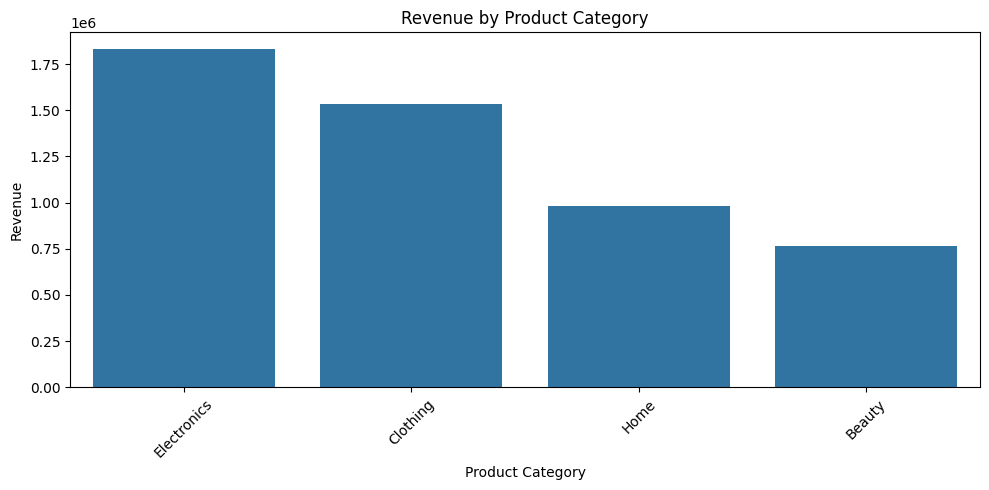

In [210]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=category_analysis.reset_index(),
    x="product_category",
    y="revenue"
)

plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("category_revenue.png")
plt.show()

# Regional Analysis

In [211]:
region_analysis = (
    df.groupby("region")
    .agg(
        revenue=("revenue", "sum"),
        orders=("order_id", "nunique"),
        average_delivery=("delivery_days", "mean"),
        average_rating=("customer_rating", "mean")
    )
    .sort_values("revenue", ascending=False)
)

region_analysis

,revenue,orders,average_delivery,average_rating
region,,,,
West,1345582.16,1289,6.082234,2.961521
North,1281508.45,1276,6.118339,2.993182
South,1246640.90,1208,6.173013,2.967798
East,1236044.23,1227,6.104319,2.973187


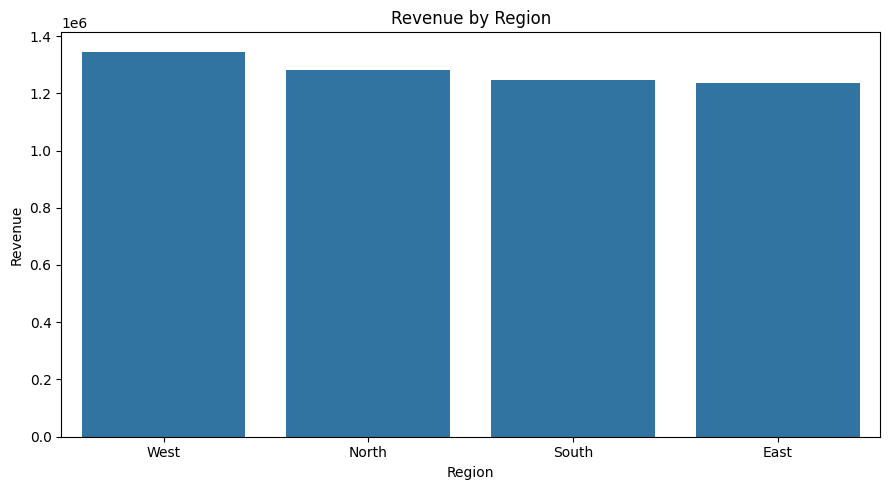

In [212]:
plt.figure(figsize=(9,5))

sns.barplot(
    data=region_analysis.reset_index(),
    x="region",
    y="revenue"
)

plt.title("Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Revenue")

plt.tight_layout()

plt.savefig("regional_revenue.png")
plt.show()

# Customer Analysis

In [213]:
top_customers = (
    df.groupby("customer_id")
    .agg(
        total_revenue=("revenue", "sum"),
        total_orders=("order_id", "nunique"),
        average_rating=("customer_rating", "mean")
    )
    .sort_values("total_revenue", ascending=False)
    .head(10)
)

top_customers

,total_revenue,total_orders,average_rating
customer_id,,,
1663,17680.69,14,2.750000
1955,16265.15,10,3.490000
1675,15036.46,11,2.981818
1276,15023.71,11,3.036364
1647,14894.97,11,3.027273
1804,14330.98,10,3.040000
1193,14151.65,7,3.271429
1836,14110.78,9,3.311111
1957,13956.95,12,3.175000


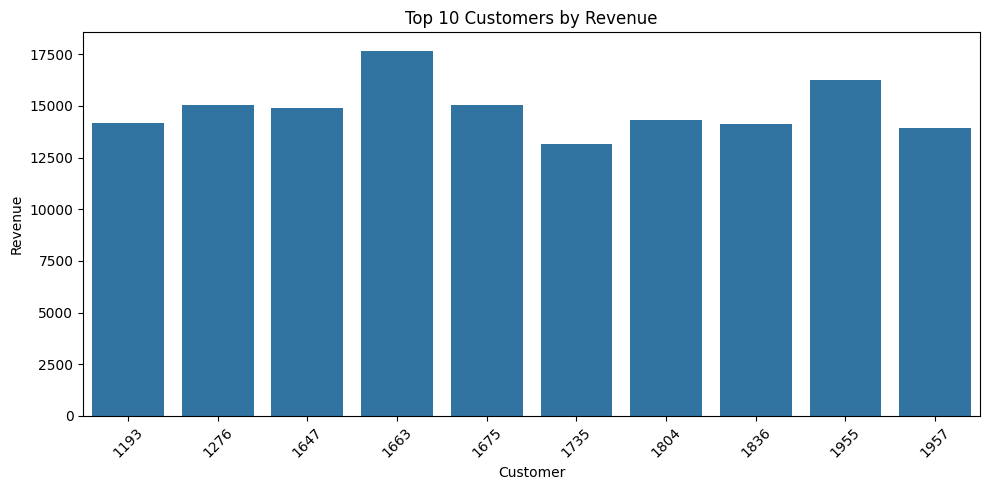

In [214]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=top_customers.reset_index(),
    x="customer_id",
    y="total_revenue"
)

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Customer")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("top_customers.png")
plt.show()

# Payment Analysis

In [215]:
payment_analysis = (
    df.groupby("payment_method")
    .agg(
        orders=("order_id", "nunique"),
        revenue=("revenue", "sum")
    )
    .sort_values("revenue", ascending=False)
)

payment_analysis

,orders,revenue
payment_method,,
Card,2270,2366248.20
COD,1774,1788408.44
Wallet,956,955119.10


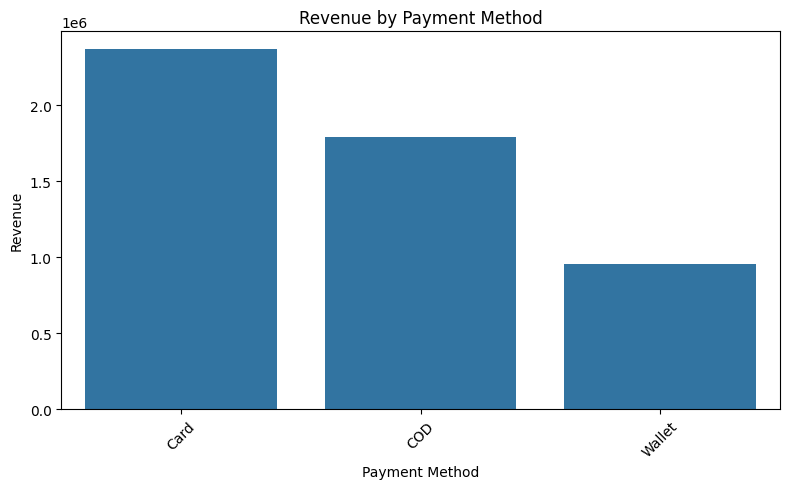

In [216]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=payment_analysis.reset_index(),
    x="payment_method",
    y="revenue"
)

plt.title("Revenue by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("payment_revenue.png")
plt.show()

# Delivery Analysis

In [217]:
delivery_analysis = (
    df.groupby("region")
    .agg(
        average_delivery=("delivery_days", "mean"),
        average_rating=("customer_rating", "mean"),
        revenue=("revenue", "sum")
    )
    .sort_values("average_delivery")
)

delivery_analysis

,average_delivery,average_rating,revenue
region,,,
West,6.082234,2.961521,1345582.16
East,6.104319,2.973187,1236044.23
North,6.118339,2.993182,1281508.45
South,6.173013,2.967798,1246640.90


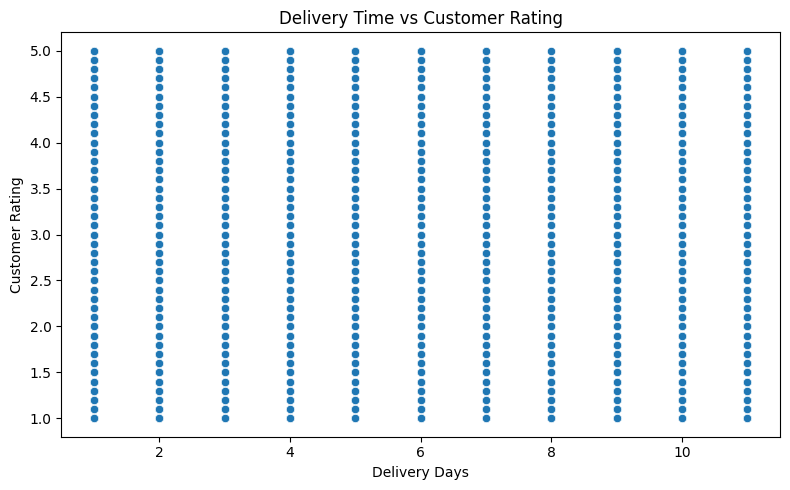

In [218]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="delivery_days",
    y="customer_rating"
)

plt.title("Delivery Time vs Customer Rating")
plt.xlabel("Delivery Days")
plt.ylabel("Customer Rating")

plt.tight_layout()

plt.savefig("delivery_rating.png")
plt.show()

# Discount Analysis

In [219]:
discount_analysis = (
    df.groupby("discount")
    .agg(
        orders=("order_id", "nunique"),
        revenue=("revenue", "sum"),
        average_rating=("customer_rating", "mean")
    )
    .sort_values("revenue", ascending=False)
)

discount_analysis

,orders,revenue,average_rating
discount,,,
0.02,160,201162.79,2.901875
0.03,138,174058.16,2.901449
0.25,171,170036.42,2.759649
0.06,133,165679.87,2.879699
0.14,138,164218.61,3.089855
0.11,146,161714.51,2.986986
0.21,155,161489.73,2.990968
0.08,142,160579.10,2.892254
0.05,128,158456.80,2.857031


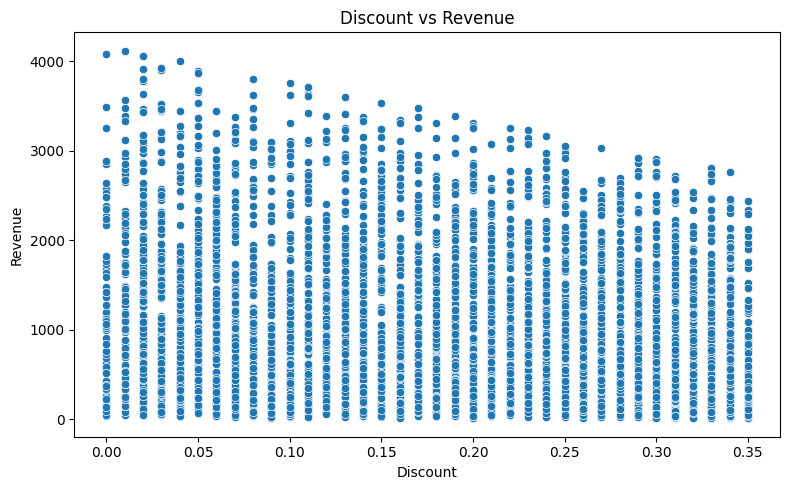

In [220]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="discount",
    y="revenue"
)

plt.title("Discount vs Revenue")
plt.xlabel("Discount")
plt.ylabel("Revenue")

plt.tight_layout()

plt.savefig("discount_revenue.png")
plt.show()

# Correlation Analysis

In [221]:
numeric_columns = [
    "quantity",
    "unit_price",
    "discount",
    "delivery_days",
    "customer_rating",
    "revenue"
]

In [222]:
correlation = df[numeric_columns].corr()
correlation

,quantity,unit_price,discount,delivery_days,customer_rating,revenue
quantity,1.000000,0.001498,-0.004302,-0.008748,0.019168,0.623564
unit_price,0.001498,1.000000,0.013215,0.015623,0.005025,0.678032
discount,-0.004302,0.013215,1.000000,-0.000382,0.012776,-0.139296
delivery_days,-0.008748,0.015623,-0.000382,1.000000,-0.017625,0.005444
customer_rating,0.019168,0.005025,0.012776,-0.017625,1.000000,0.012446
revenue,0.623564,0.678032,-0.139296,0.005444,0.012446,1.000000


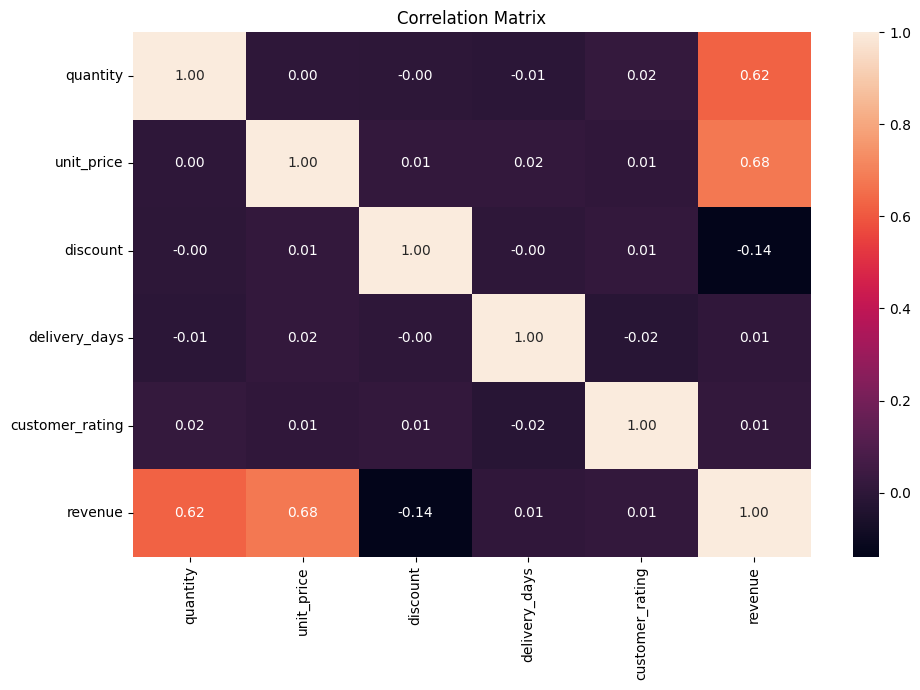

In [223]:
plt.figure(figsize=(10,7))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.tight_layout()

plt.savefig("correlation_matrix.png")
plt.show()

In [224]:
df.to_csv(
    "ecommerce_cleaned.csv",
    index=False
)